# Care Leavers and Progression to Higher Education
### How far behind do care leavers start, and how much wider does the gap get at the most selective universities?

This notebook tells the care leaver progression story from **real, published, openly licensed government data**: the Department for Education's *Widening Participation in Higher Education* release (2023/24, published 2025), **All Characteristics** dataset.

**One finding, sharpened three ways:**

- **Angle 1 (the headline gap):** what share of care leavers reach higher education at all, versus everyone else.
- **Angle 2 (the selectivity gap):** the same comparison but for *high tariff* providers, the DfE's published proxy for the most selective universities (heavy Russell Group overlap). This is where the gap widens sharply.
- **Angle 3 (the trend):** has any of it moved over time, or is the gap stuck?

**Two questions, never conflated:**
- **Q_A** = of all care leavers, what % reach (high tariff) HE? *(denominator = care leavers)* — this dataset answers it.
- **Q_B** = of all students at a selective university, what % are care leavers? *(denominator = university students)* — needs restricted provider-level HESA data, **not claimed here**.

> **Source:** DfE, *Widening Participation in Higher Education*, academic year 2023/24, "All Characteristics" (National). Open Government Licence v3. Reuse with attribution.


## 0. Setup

In [1]:
import io
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)


## 1. Get the data

The **All Characteristics** dataset carries care leaver as one value in its `breakdown` column, alongside the "All Other Pupils" comparator, and includes both an overall and a **high tariff** progression rate. That is everything the three angles need.

The catalogue CSV endpoint below is the confirmed live ID for this dataset. It downloads once and caches locally. If your network blocks GOV.UK service domains, the fallback message tells you exactly which file to grab by hand.

In [2]:
# Confirmed EES catalogue ID for "All Characteristics" (National), WP 2023/24 release.
# This is the file whose breakdown column includes 'Care Leaver'.
DATASET_ID = "168795a4-26a0-4b29-8b9e-442b5e5f9fcf"
CSV_URL = ("https://explore-education-statistics.service.gov.uk"
           f"/data-catalogue/data-set/{DATASET_ID}/csv")
LOCAL_CSV = DATA_DIR / "wp_all_characteristics.csv"

def load_wp():
    if LOCAL_CSV.exists():
        print(f"Using cached file {LOCAL_CSV}")
        return pd.read_csv(LOCAL_CSV, low_memory=False)
    try:
        print("Downloading All Characteristics dataset from EES...")
        req = urllib.request.Request(CSV_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp:
            raw = resp.read()
        LOCAL_CSV.write_bytes(raw)
        print(f"Saved to {LOCAL_CSV} ({len(raw)/1e6:.2f} MB)")
        return pd.read_csv(io.BytesIO(raw), low_memory=False)
    except Exception as e:
        print("Live download failed:", e)
        print("\nMANUAL FALLBACK:")
        print("  1. Open the WP 2023/24 'Explore data' page.")
        print("  2. In the data set list, find 'All Characteristics' (National).")
        print("  3. Download (ZIP), unzip, and save the CSV as:")
        print(f"     {LOCAL_CSV.resolve()}")
        print("  4. Re-run this cell.")
        return None

df = load_wp()
if df is not None:
    print(df.shape)
    df.head()

Using cached file data/wp_all_characteristics.csv
(745, 12)


## 2. Confirm the schema

This file uses a two-level breakdown: `breakdown_topic` is the characteristic family (e.g. `Care Leaver`, `FSM Status`, `POLAR`) and `breakdown` is the value within it (e.g. `Care Leaver`, `All Other Pupils`). The rate columns are lowercase snake_case. This cell just prints what's there so nothing downstream is guessing.

In [3]:
if df is not None:
    print("COLUMNS:")
    for c in df.columns:
        print("  ", c)

    print("\nbreakdown_topic values:")
    for v in sorted(df['breakdown_topic'].dropna().unique()):
        print("  ", repr(v))

    print("\nbreakdown values within 'Care Leaver':")
    print("  ", list(df.loc[df['breakdown_topic'] == 'Care Leaver', 'breakdown'].unique()))

COLUMNS:
   time_period
   time_identifier
   geographic_level
   country_code
   country_name
   breakdown_topic
   breakdown
   progression_rate
   high_tariff_progression_rate
   number_of_he_students
   number_of_high_tariff_he_students
   number_of_students

breakdown_topic values:
   'Care Leaver'
   'Children in Need'
   'Disadvantage'
   'Ethnicity Major'
   'Ethnicity Minor'
   'FSM Status'
   'First Language'
   'Looked After Status'
   'POLAR'
   'SEN Provision'
   'SEN Status'
   'Sex'

breakdown values within 'Care Leaver':
   ['Care Leaver', 'All Other Pupils']


## 3. Mapping

Confirmed against the schema above, no guessing. The care leaver topic holds exactly two groups: `Care Leaver` and `All Other Pupils`.

Note on data conventions: looked-after and care leaver figures are rounded (rates to the nearest %, counts to the nearest 10) for disclosure control, and some cells carry `'c'` (confidential) or `'x'` (not applicable). The numeric conversion below turns those flags into `NaN` instead of crashing.

In [4]:
TOPIC_COL   = 'breakdown_topic'
GROUP_COL   = 'breakdown'
RATE_COL    = 'progression_rate'
RATE_HT_COL = 'high_tariff_progression_rate'
YEAR_COL    = 'time_period'
GEO_COL     = 'geographic_level'

CARE_TOPIC  = 'Care Leaver'        # the breakdown_topic family
CARE_VALUE  = 'Care Leaver'        # the care leaver group within it
OTHER_VALUE = 'All Other Pupils'   # the comparator group

def fmt_year(ycol):
    """202324 -> '2023/24'. Leaves anything unexpected untouched."""
    s = ycol.astype(str)
    return s.str.replace(r'^(\d{4})(\d{2})$', r'\1/\2', regex=True)

def to_num(series):
    """Coerce rates to float, turning 'c'/'x'/blank flags into NaN."""
    return pd.to_numeric(series, errors='coerce')

## 4. Published anchor (the honesty check)

The DfE release states the headline numbers in plain text. We hold them as a documented anchor: if the figures computed from the CSV don't land here, the mapping is wrong.

From the **2023/24 release**:

| Measure | Care leavers | All other pupils |
|---|---|---|
| Reached **any** HE by age 19 | **13%** | **46%** |
| Reached **high tariff** HE by age 19 | **2%** | **13%** |

Care leavers reach HE at roughly a **third** the rate of their peers, and reach the most selective universities at roughly a **sixth** the rate. The gap widens as selectivity rises. That is the story.

In [5]:
PUBLISHED = {
    'any_HE':      {'care_leaver': 13, 'other': 46},
    'high_tariff': {'care_leaver': 2,  'other': 13},
}
def ratio(d): return d['other'] / d['care_leaver']

print("ANCHOR, from DfE 2023/24 release text")
print(f"  Any HE      : care leavers {PUBLISHED['any_HE']['care_leaver']}% "
      f"vs others {PUBLISHED['any_HE']['other']}%  -> {ratio(PUBLISHED['any_HE']):.1f}x")
print(f"  High tariff : care leavers {PUBLISHED['high_tariff']['care_leaver']}% "
      f"vs others {PUBLISHED['high_tariff']['other']}%  -> {ratio(PUBLISHED['high_tariff']):.1f}x")

ANCHOR, from DfE 2023/24 release text
  Any HE      : care leavers 13% vs others 46%  -> 3.5x
  High tariff : care leavers 2% vs others 13%  -> 6.5x


## 5. Compute the same figures from the CSV and cross-check

In [6]:
computed = {}

if df is not None:
    care = df[df[TOPIC_COL] == CARE_TOPIC].copy()
    if GEO_COL in care.columns:
        care = care[care[GEO_COL].astype(str).str.contains('National', case=False, na=False)]
    care['year'] = fmt_year(care[YEAR_COL])
    latest = sorted(care['year'].dropna().unique())[-1]
    print("Latest year in file:", latest, "\n")

    def grab(group, col):
        sub = care[(care[GROUP_COL] == group) & (care['year'] == latest)]
        if sub.empty or col not in sub.columns:
            return None
        vals = to_num(sub[col]).dropna()
        return float(vals.iloc[0]) if len(vals) else None

    computed['any_HE'] = {'care_leaver': grab(CARE_VALUE, RATE_COL),
                          'other':       grab(OTHER_VALUE, RATE_COL)}
    computed['high_tariff'] = {'care_leaver': grab(CARE_VALUE, RATE_HT_COL),
                               'other':       grab(OTHER_VALUE, RATE_HT_COL)}

    print("COMPUTED from CSV:")
    for k, d in computed.items():
        print(f"  {k:11s}: care leavers {d['care_leaver']}  vs others {d['other']}")
    print("\nShould match the section 4 anchor (allowing for rounding).")
else:
    print("CSV not loaded, falling back to published anchor.")
    computed = {k: dict(v) for k, v in PUBLISHED.items()}

Latest year in file: 2023/24 

COMPUTED from CSV:
  any_HE     : care leavers 13.0  vs others 46.0
  high_tariff: care leavers 2.0  vs others 13.0

Should match the section 4 anchor (allowing for rounding).


## 6. Angle 1 vs Angle 2, the widening gap

One chart, the whole argument. As the eye moves from "any university" to "the most selective universities", the care leaver bar collapses far faster than the comparator.

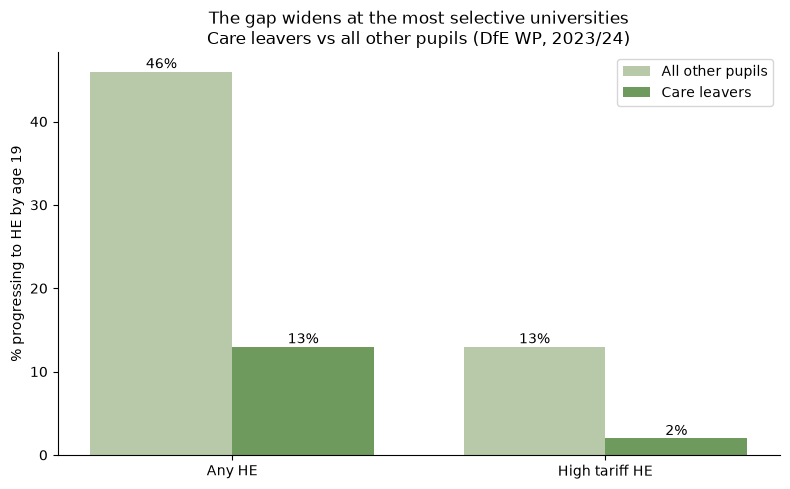

Any HE        : others reach HE 3.5x as often
High tariff HE: others reach it 6.5x as often


In [7]:
def pick(stage, who):
    v = computed.get(stage, {}).get(who)
    return v if v is not None else PUBLISHED[stage][who]

stages = [('Any HE', 'any_HE'), ('High tariff HE', 'high_tariff')]
labels     = [lab for lab, _ in stages]
care_vals  = [pick(key, 'care_leaver') for _, key in stages]
other_vals = [pick(key, 'other') for _, key in stages]

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, other_vals, w, label='All other pupils', color='#b8c9a9')
b2 = ax.bar(x + w/2, care_vals,  w, label='Care leavers',     color='#6f9a5e')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('% progressing to HE by age 19')
ax.set_title('The gap widens at the most selective universities\n'
             'Care leavers vs all other pupils (DfE WP, 2023/24)')
ax.legend()
for bars in (b1, b2):
    for r in bars:
        ax.annotate(f'{r.get_height():.0f}%',
                    (r.get_x() + r.get_width()/2, r.get_height()),
                    ha='center', va='bottom', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / 'gap_any_vs_hightariff.png', dpi=150)
plt.show()

print(f"Any HE        : others reach HE {pick('any_HE','other')/pick('any_HE','care_leaver'):.1f}x as often")
print(f"High tariff HE: others reach it {pick('high_tariff','other')/pick('high_tariff','care_leaver'):.1f}x as often")

## 6b. Cohort comparisons, care leavers and looked-after children side by side

The file holds two distinct disadvantaged cohorts, and they are **not** the same population:

- **Care leaver** — local-authority care experience, looked after at least 13 weeks after the 14th birthday including time after 16.
- **Looked after continuously for 12 months or more** — a different, overlapping-but-not-identical cohort.

Comparing them is its own small finding. This section computes every buildable comparison straight from the file (nothing hardcoded) and lays them out as ratios.

**What's computable here vs what isn't:**
- Care leaver vs all other pupils (any HE, and high tariff) — computable.
- Looked-after-12m+ vs all other pupils (any HE, and high tariff) — computable.
- Care leaver vs looked-after-12m+ (any HE) — computable, and counterintuitive: the looked-after cohort progresses slightly *higher*.
- "Any time in care" vs "12 months continuous" — **not in this file.** This WP dataset has a single looked-after cohort ("12 months or more"). The broader any-care vs continuous-care split lives in a different DfE publication (*Children Looked After in England*). Flagged, not faked.

> **Rounding caution:** high-tariff rates are rounded to the nearest whole %, so both cohorts read as 2%. Don't over-interpret tiny differences at the high-tariff end.

In [8]:
CARE_TOPIC_NAME = 'Care Leaver'
LAC_TOPIC_NAME  = 'Looked After Status'
LAC_VALUE       = 'Looked after continuously for 12 months or more'

def latest_rate(topic, group, col):
    """Pull one rounded rate for a cohort in the latest year, flags -> NaN."""
    if df is None:
        return None
    sub = df[df[TOPIC_COL] == topic].copy()
    if GEO_COL in sub.columns:
        sub = sub[sub[GEO_COL].astype(str).str.contains('National', case=False, na=False)]
    sub['year'] = fmt_year(sub[YEAR_COL])
    yr = sorted(sub['year'].dropna().unique())[-1]
    row = sub[(sub[GROUP_COL] == group) & (sub['year'] == yr)]
    if row.empty or col not in row.columns:
        return None
    vals = to_num(row[col]).dropna()
    return float(vals.iloc[0]) if len(vals) else None

# Pull the six numbers we need (with anchor fallback if CSV absent)
cl_any  = latest_rate(CARE_TOPIC_NAME, CARE_VALUE,  RATE_COL)    or PUBLISHED['any_HE']['care_leaver']
cl_ht   = latest_rate(CARE_TOPIC_NAME, CARE_VALUE,  RATE_HT_COL) or PUBLISHED['high_tariff']['care_leaver']
oth_any = latest_rate(CARE_TOPIC_NAME, OTHER_VALUE, RATE_COL)    or PUBLISHED['any_HE']['other']
oth_ht  = latest_rate(CARE_TOPIC_NAME, OTHER_VALUE, RATE_HT_COL) or PUBLISHED['high_tariff']['other']
lac_any = latest_rate(LAC_TOPIC_NAME,  LAC_VALUE,   RATE_COL)
lac_ht  = latest_rate(LAC_TOPIC_NAME,  LAC_VALUE,   RATE_HT_COL)

print("Pulled rates (latest year):")
print(f"  Care leaver       : any {cl_any}%   high tariff {cl_ht}%")
print(f"  Looked after 12m+ : any {lac_any}%   high tariff {lac_ht}%")
print(f"  All other pupils  : any {oth_any}%   high tariff {oth_ht}%")

comparisons = [
    ("Care leaver vs all other pupils (any HE)",        cl_any, oth_any),
    ("Care leaver vs all other pupils (high tariff)",   cl_ht,  oth_ht),
    ("Looked after 12m+ vs all other pupils (any HE)",  lac_any, oth_any),
    ("Looked after 12m+ vs all other (high tariff)",    lac_ht,  oth_ht),
    ("Care leaver vs looked after 12m+ (any HE)",       cl_any, lac_any),
]

rows = []
for label, group_val, ref_val in comparisons:
    if group_val and ref_val:
        rows.append({'Comparison': label,
                     'Group rate': f"{group_val:.0f}%",
                     'Reference rate': f"{ref_val:.0f}%",
                     'Reference is': f"{ref_val/group_val:.1f}x higher"})
    else:
        rows.append({'Comparison': label, 'Group rate': 'n/a',
                     'Reference rate': 'n/a', 'Reference is': 'not in this file'})

comparison_table = pd.DataFrame(rows)
comparison_table

Pulled rates (latest year):
  Care leaver       : any 13.0%   high tariff 2.0%
  Looked after 12m+ : any 15.0%   high tariff 2.0%
  All other pupils  : any 46.0%   high tariff 13.0%


,Comparison,Group rate,Reference rate,Reference is
0,Care leaver vs all other pupils (any HE),13%,46%,3.5x higher
1,Care leaver vs all other pupils (high tariff),2%,13%,6.5x higher
2,Looked after 12m+ vs all other pupils (any HE),15%,46%,3.1x higher
3,Looked after 12m+ vs all other (high tariff),2%,13%,6.5x higher
4,Care leaver vs looked after 12m+ (any HE),13%,15%,1.2x higher


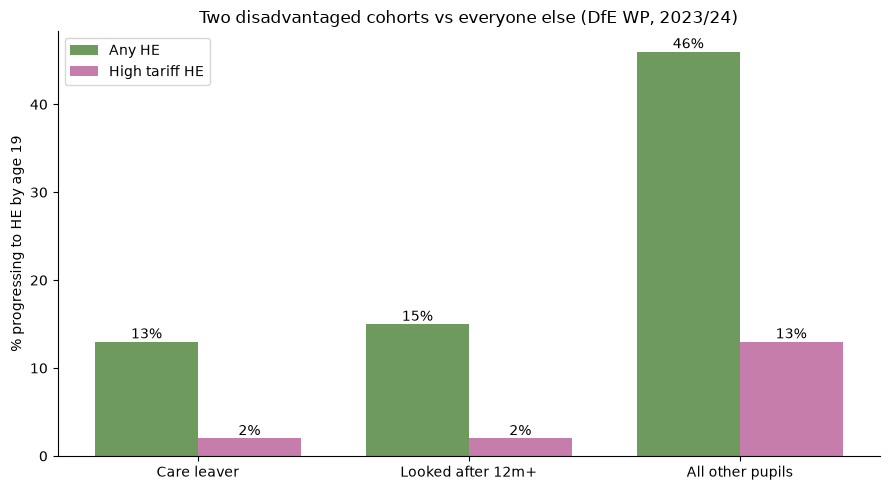

Care leavers reach any HE 3.5x less often than peers; high tariff 6.5x less often.
Looked-after-12m+ reach any HE 3.1x less often than peers.
Note: looked-after-12m+ (15%) progress slightly higher than care leavers (13%), 1.2x, different cohorts.


In [9]:
# Grouped chart: both cohorts vs comparator, any HE and high tariff
cohorts = ['Care leaver', 'Looked after 12m+', 'All other pupils']
any_vals = [cl_any, lac_any, oth_any]
ht_vals  = [cl_ht,  lac_ht,  oth_ht]

x = np.arange(len(cohorts)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, any_vals, w, label='Any HE',        color='#6f9a5e')
b2 = ax.bar(x + w/2, ht_vals,  w, label='High tariff HE', color='#c77dab')
ax.set_xticks(x); ax.set_xticklabels(cohorts)
ax.set_ylabel('% progressing to HE by age 19')
ax.set_title('Two disadvantaged cohorts vs everyone else (DfE WP, 2023/24)')
ax.legend()
for bars in (b1, b2):
    for r in bars:
        h = r.get_height()
        if h is not None and not np.isnan(h):
            ax.annotate(f'{h:.0f}%', (r.get_x()+r.get_width()/2, h),
                        ha='center', va='bottom', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / 'cohort_comparison.png', dpi=150)
plt.show()

print(f"Care leavers reach any HE {oth_any/cl_any:.1f}x less often than peers; "
      f"high tariff {oth_ht/cl_ht:.1f}x less often.")
if lac_any:
    print(f"Looked-after-12m+ reach any HE {oth_any/lac_any:.1f}x less often than peers.")
    print(f"Note: looked-after-12m+ ({lac_any:.0f}%) progress slightly higher than "
          f"care leavers ({cl_any:.0f}%), {lac_any/cl_any:.1f}x, different cohorts.")

## 7. Angle 3, the trend over time

Care leaver was published as a distinct measure only recently, so the line may be short, which is itself worth a sentence. The comparator (all other pupils) runs the full series.

> **Caveat baked into the chart:** DfE warns KS5 reform and pandemic disruption reduce year-on-year comparability, especially around 2020-2022.

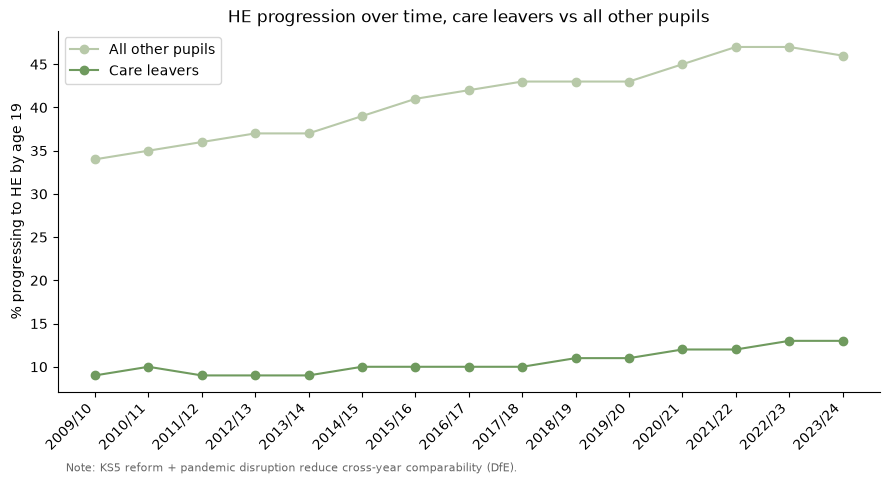

Care leaver series covers 2009/10 to 2023/24 (15 points).


In [10]:
if df is not None:
    care = df[df[TOPIC_COL] == CARE_TOPIC].copy()
    if GEO_COL in care.columns:
        care = care[care[GEO_COL].astype(str).str.contains('National', case=False, na=False)]
    care['year'] = fmt_year(care[YEAR_COL])
    care[RATE_COL] = to_num(care[RATE_COL])

    def series(group):
        s = care[care[GROUP_COL] == group][['year', RATE_COL]].dropna().sort_values('year')
        return s

    cl = series(CARE_VALUE)
    ot = series(OTHER_VALUE)

    if len(cl):
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(ot['year'], ot[RATE_COL], marker='o', color='#b8c9a9', label='All other pupils')
        ax.plot(cl['year'], cl[RATE_COL], marker='o', color='#6f9a5e', label='Care leavers')
        ax.set_ylabel('% progressing to HE by age 19')
        ax.set_title('HE progression over time, care leavers vs all other pupils')
        ax.legend()
        ax.spines[['top', 'right']].set_visible(False)
        ax.text(0.01, -0.22,
                'Note: KS5 reform + pandemic disruption reduce cross-year comparability (DfE).',
                transform=ax.transAxes, fontsize=8, color='#666')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(DATA_DIR / 'progression_trend.png', dpi=150)
        plt.show()
        print(f"Care leaver series covers {cl['year'].iloc[0]} to {cl['year'].iloc[-1]} "
              f"({len(cl)} points).")
    else:
        print("No care leaver time-series rows, the measure may exist for the latest year only.")
else:
    print("CSV not loaded, see section 1 fallback.")

## 8. The deliverable, a clean summary table

In [11]:
summary = pd.DataFrame([
    {'Angle': '1. Any HE (Q_A)',
     'Care leavers': f"{pick('any_HE','care_leaver'):.0f}%",
     'All other pupils': f"{pick('any_HE','other'):.0f}%",
     'Gap': f"{pick('any_HE','other')/pick('any_HE','care_leaver'):.1f}x",
     'Reading': 'Care leavers reach HE about a third as often.'},
    {'Angle': '2. High tariff HE (Q_A, selective)',
     'Care leavers': f"{pick('high_tariff','care_leaver'):.0f}%",
     'All other pupils': f"{pick('high_tariff','other'):.0f}%",
     'Gap': f"{pick('high_tariff','other')/pick('high_tariff','care_leaver'):.1f}x",
     'Reading': 'At the most selective unis the gap roughly doubles.'},
])
summary

,Angle,Care leavers,All other pupils,Gap,Reading
0,1. Any HE (Q_A),13%,46%,3.5x,Care leavers reach HE about a third as often.
1,"2. High tariff HE (Q_A, selective)",2%,13%,6.5x,At the most selective unis the gap roughly dou...


## 9. Provenance and honesty notes, write these into the piece

- **Source:** DfE, *Widening Participation in Higher Education*, academic year 2023/24 (published 2025), "All Characteristics" dataset, National. Open Government Licence v3.
- **"High tariff" is a proxy, not the Russell Group:** the DfE's high-tariff provider group overlaps heavily with the Russell Group but is **not identical**. Write "most selective / high tariff universities", not "Russell Group", unless you separately source an RG-specific figure.
- **Which question this answers:** every percentage here is **Q_A** (of all care leavers, what share progress). The dataset does **not** support Q_B (what share of a university's students are care leavers), that needs restricted provider-level HESA data. Keep the two distinct in the copy.
- **Care leaver definition:** local-authority reported; young people looked after at least 13 weeks after their 14th birthday including time after 16. Note care leavers include unaccompanied asylum-seeking children, which affects comparability over time. Cohort matched from the National Pupil Database through to HESA/ILR.
- **Rounding and suppression:** care/looked-after figures are rounded (rates to nearest %, counts to nearest 10); `'c'` marks confidential cells, `'x'` not applicable. The notebook coerces those to NaN.
- **Comparability caveat:** KS5 reform and pandemic disruption reduce year-on-year comparability, flag whenever citing the trend.
- **Undercount direction:** care status relies on records and self-identification; some eligible young people are never flagged, so these rates are if anything a **floor**.
- **Headline framing:** "care leavers reach the most selective universities at roughly a sixth the rate of their peers" is defensible and sourced. Avoid implying a single hard "X% of Russell Group students are care leavers", you don't have provider-level data for that.


---

# Chapter 2 — The application journey

Chapter 1 used DfE data to answer *how many care leavers reach university*. This chapter switches to **UCAS data** to ask a different question: among care-experienced people who do apply, *what does their journey look like* — how old are they, what do they study, and do they reach selective providers?

**Source switch, stated plainly.** This is a different dataset and a different cohort from Chapter 1:
- Chapter 1 = DfE *Widening Participation*, school pupils aged 15 tracked to HE by age 19, England.
- Chapter 2 = UCAS *Next Steps: students from a care background* supporting data, UCAS applicants who self-identify as care-experienced, UK.

These cannot be chained into one funnel (different denominators, different definitions of "care", different coverage). They are two lenses on the same population, kept separate on purpose.

> **Source:** UCAS, *Next Steps: What is the experience of students from a care background in education?* (2022), supporting data tables. UCAS applicant data, UK.
>
> **Conventions in these files:** each CSV has a 10-row metadata header; counts are rounded to the nearest 10; percentages are suppressed where either contributing group is under 20 (shown as NaN).

## 10. UCAS data loader

Every file in the Next Steps pack shares the same shape: a 10-row metadata header, then a tidy table. Counts arrive as comma-strings (`"1,740"`) and percentages as strings (`"27.4%"`), so the loader strips and converts them.

In [12]:
UCAS_DIR = DATA_DIR / 'next-steps-care-background-data-files'

def load_ucas(filename):
    """Load a Next Steps CSV: skip 10 metadata rows, clean counts and percentages."""
    df_u = pd.read_csv(UCAS_DIR / filename, skiprows=10, dtype=str)
    for col in df_u.columns:
        s = df_u[col].astype(str).str.strip()
        if s.str.contains('%', na=False).any():
            df_u[col] = pd.to_numeric(s.str.replace('%', '', regex=False), errors='coerce')
        else:
            num = pd.to_numeric(s.str.replace(',', '', regex=False), errors='coerce')
            if num.notna().mean() > 0.5:   # convert count/year cols, leave text labels alone
                df_u[col] = num
    return df_u

# sanity check
if UCAS_DIR.exists():
    _age = load_ucas('Care-experienced applicants - age.csv')
    print("Loader OK. Age file shape:", _age.shape)
    print("Care categories:", list(_age['Care category'].unique()))
    print("Years:", sorted(_age['Year'].dropna().unique()))
else:
    print("UCAS folder not found. Unzip the Next Steps data pack into:")
    print(" ", UCAS_DIR.resolve())

Loader OK. Age file shape: (80, 7)
Care categories: ['Not care experienced', 'Care experienced']
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


## 11. Angle A — care-experienced applicants apply much older

The clearest finding in the UCAS data: care-experienced applicants are far more spread across age, and far less concentrated at 18, than other applicants. This is the raw version of the widely-quoted "more likely to apply at 21+" headline, computed here directly.

Age distribution of applicants, 2022 (% of each group):
Care category  Care experienced  Not care experienced
Age                                                  
17 and under                0.5                   0.4
18                         41.1                  58.1
19                         16.2                  15.4
20                          7.5                   5.6
21 - 24                    15.0                   8.8
25 - 29                     7.2                   4.2
30 - 34                     4.4                   2.6
35 and over                 8.1                   4.9

Applying aged 21+:  care-experienced 34.7%  vs  others 20.5%
-> care-experienced applicants are 1.7x as likely to apply at 21+


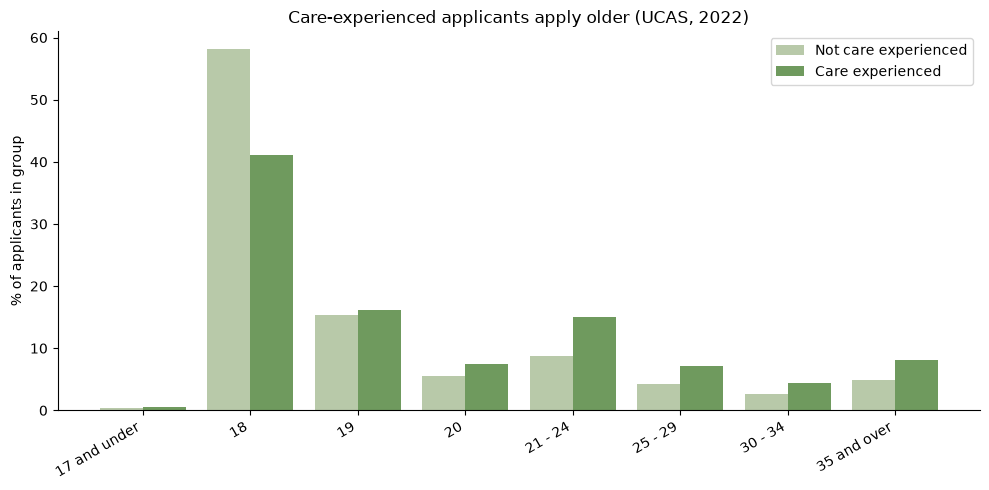

In [13]:
AGE_ORDER = ['17 and under', '18', '19', '20', '21 - 24', '25 - 29', '30 - 34', '35 and over']
OLDER = ['21 - 24', '25 - 29', '30 - 34', '35 and over']

age = load_ucas('Care-experienced applicants - age.csv')
latest_yr = int(age['Year'].max())

dist = (age[age['Year'] == latest_yr]
        .pivot_table(index='Age', columns='Care category',
                     values='Proportion of applicants')
        .reindex(AGE_ORDER))

print(f"Age distribution of applicants, {latest_yr} (% of each group):")
print(dist.to_string())

def share_21plus(cat):
    sub = age[(age['Year'] == latest_yr) & (age['Care category'] == cat)]
    return sub[sub['Age'].isin(OLDER)]['Proportion of applicants'].sum()

ce_older  = share_21plus('Care experienced')
nce_older = share_21plus('Not care experienced')
print(f"\nApplying aged 21+:  care-experienced {ce_older:.1f}%  vs  others {nce_older:.1f}%")
print(f"-> care-experienced applicants are {ce_older/nce_older:.1f}x as likely to apply at 21+")

# Chart: grouped bars by age band
fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(AGE_ORDER)); w = 0.4
ce_vals  = dist['Care experienced'].values
nce_vals = dist['Not care experienced'].values
ax.bar(xpos - w/2, nce_vals, w, label='Not care experienced', color='#b8c9a9')
ax.bar(xpos + w/2, ce_vals,  w, label='Care experienced',     color='#6f9a5e')
ax.set_xticks(xpos); ax.set_xticklabels(AGE_ORDER, rotation=30, ha='right')
ax.set_ylabel('% of applicants in group')
ax.set_title(f'Care-experienced applicants apply older (UCAS, {latest_yr})')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / 'ucas_age_distribution.png', dpi=150)
plt.show()

## 12. Angle B — do care-experienced applicants reach selective providers?

This is the bridge back to Chapter 1. Chapter 1 showed care leavers are six times less likely to reach *high tariff* universities. UCAS records the tariff group of providers applicants actually apply to, so we can see the selectivity pattern from the applicant side.

In [14]:
tariff = load_ucas('Care-experienced applicants - provider tariff group.csv')
print("Columns:", list(tariff.columns))
print("Tariff groups:", list(tariff[[c for c in tariff.columns if 'tariff' in c.lower() or 'Tariff' in c][0]].unique())
      if any('ariff' in c for c in tariff.columns) else "check columns above")
print()
print(tariff.head(12).to_string(index=False))

# Identify the tariff label column (name can vary slightly)
tariff_col = next((c for c in tariff.columns if 'ariff' in c), None)
prop_col   = next((c for c in tariff.columns if 'Proportion of applicants' in c), None)

if tariff_col and prop_col:
    ty = int(tariff['Year'].max())
    comp = (tariff[tariff['Year'] == ty]
            .pivot_table(index=tariff_col, columns='Care category', values=prop_col))
    print(f"\nProvider tariff group, share of applicants by care status ({ty}):")
    print(comp.to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    idx = np.arange(len(comp.index)); w = 0.4
    if 'Not care experienced' in comp.columns:
        ax.bar(idx - w/2, comp['Not care experienced'].values, w,
               label='Not care experienced', color='#b8c9a9')
    if 'Care experienced' in comp.columns:
        ax.bar(idx + w/2, comp['Care experienced'].values, w,
               label='Care experienced', color='#6f9a5e')
    ax.set_xticks(idx); ax.set_xticklabels(comp.index, rotation=20, ha='right')
    ax.set_ylabel('% of applicants')
    ax.set_title(f'Applications by provider tariff group, care status ({ty})')
    ax.legend(); ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'ucas_tariff_group.png', dpi=150)
    plt.show()
else:
    print("\nColumn names differ from expected, inspect the printout above and adjust.")

Columns: ['Year', 'Care category', 'Provider tariff group', 'Main scheme applications', 'Accepted applicants', 'Proportion of main scheme applications', 'Proportion of accepted applicants']
Tariff groups: ['Lower tariff', 'Medium tariff', 'Higher tariff']

 Year        Care category Provider tariff group  Main scheme applications  Accepted applicants  Proportion of main scheme applications  Proportion of accepted applicants
 2018 Not care experienced          Lower tariff                    708210               164110                                    33.5                               38.8
 2018 Not care experienced         Medium tariff                    685790               144710                                    32.4                               34.2
 2018 Not care experienced         Higher tariff                    720960               114010                                    34.1                               27.0
 2018     Care experienced          Lower tariff           

## 13. Angle C — has the care-experienced applicant count grown?

A simple time series: total care-experienced applicants per cycle, 2018 onward. Worth knowing whether the pipeline is widening or flat.

Care-experienced applicants by year:
Year
2018    5440
2019    5730
2020    6450
2021    7140
2022    8930


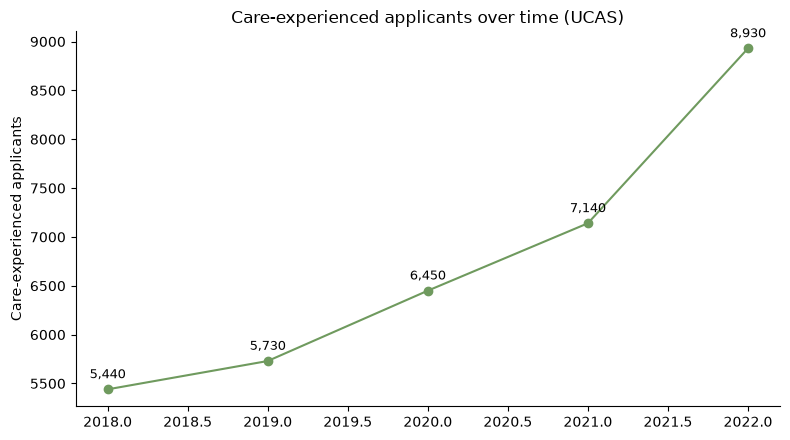


Change 2018 to 2022: +64%


In [15]:
# Total care-experienced applicants per year (sum across age bands)
ce = age[age['Care category'] == 'Care experienced']
totals = ce.groupby('Year')['Applicants'].sum()
print("Care-experienced applicants by year:")
print(totals.to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(totals.index, totals.values, marker='o', color='#6f9a5e')
ax.set_ylabel('Care-experienced applicants')
ax.set_title('Care-experienced applicants over time (UCAS)')
ax.spines[['top', 'right']].set_visible(False)
for x, y in zip(totals.index, totals.values):
    ax.annotate(f'{y:,.0f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'ucas_applicant_trend.png', dpi=150)
plt.show()

if len(totals) > 1:
    change = (totals.iloc[-1] - totals.iloc[0]) / totals.iloc[0] * 100
    print(f"\nChange {totals.index[0]} to {totals.index[-1]}: {change:+.0f}%")

## 14. Chapter 2 provenance and honesty notes

- **Source:** UCAS, *Next Steps: What is the experience of students from a care background in education?* (2022), supporting data tables. UK applicants.
- **Cohort is self-identified applicants**, people who ticked the care-experienced box on the UCAS form. This undercounts (not everyone discloses) and differs from Chapter 1's local-authority-defined care leavers. Do not merge the two cohorts.
- **This is application data, not outcomes.** It shows who applies, how old they are, and where they apply, not whether they get in, stay, or graduate. England-wide care-leaver *continuation / completion / attainment* is not available as open analysable data; HESA has stated it plans to publish an exploration of care-experienced student data, but it isn't out yet. That absence is itself a reportable point.
- **Rounding and suppression:** counts rounded to nearest 10; percentages suppressed where either group is under 20 (NaN here). Care-experienced cells are small, so expect gaps, note them rather than interpolating.
- **The age finding is the strongest:** care-experienced applicants are markedly more likely to apply at 21+, which ties directly to the over-representation of the Access to HE route among care-experienced entrants. A clean, sourced, self-computed headline.

## 15. Expanded UCAS toolkit

The Next Steps pack has 16 analysable applicant files (clean `Year / Care category / breakdown` shape) plus survey files. The survey CSVs use a Windows encoding (curly quotes as byte 0x92), so they need `encoding='latin-1'`. This upgraded loader handles both, and a generic `compare_breakdown()` helper turns any applicant file into a care vs non-care comparison.

In [16]:
def load_ucas(filename, skiprows=10):
    """Robust loader: tries utf-8 then latin-1, skips metadata header, cleans numbers."""
    path = UCAS_DIR / filename
    for enc in ('utf-8', 'latin-1'):
        try:
            df_u = pd.read_csv(path, skiprows=skiprows, dtype=str, encoding=enc)
            break
        except (UnicodeDecodeError, Exception):
            continue
    for col in df_u.columns:
        s = df_u[col].astype(str).str.strip()
        if s.str.contains('%', na=False).any():
            df_u[col] = pd.to_numeric(s.str.replace('%', '', regex=False), errors='coerce')
        else:
            num = pd.to_numeric(s.str.replace(',', '', regex=False), errors='coerce')
            if num.notna().mean() > 0.5:
                df_u[col] = num
    return df_u

def compare_breakdown(filename, breakdown_col, prop_col='Proportion of applicants',
                      year=None, order=None):
    """Return a tidy CE-vs-NCE pivot for any applicant breakdown file."""
    df_b = load_ucas(filename)
    if year is None:
        year = int(df_b['Year'].max())
    piv = (df_b[df_b['Year'] == year]
           .pivot_table(index=breakdown_col, columns='Care category', values=prop_col))
    if order:
        piv = piv.reindex(order)
    return piv, year

def grouped_bar(piv, title, xlabel='', savename=None, rotate=20, figsize=(9, 5)):
    """Standard CE-vs-NCE grouped bar from a compare_breakdown pivot."""
    fig, ax = plt.subplots(figsize=figsize)
    idx = np.arange(len(piv.index)); w = 0.4
    if 'Not care experienced' in piv.columns:
        ax.bar(idx - w/2, piv['Not care experienced'].values, w,
               label='Not care experienced', color='#b8c9a9')
    if 'Care experienced' in piv.columns:
        ax.bar(idx + w/2, piv['Care experienced'].values, w,
               label='Care experienced', color='#6f9a5e')
    ax.set_xticks(idx); ax.set_xticklabels(piv.index, rotation=rotate, ha='right')
    ax.set_ylabel('% of applicants'); ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend(); ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    if savename:
        plt.savefig(DATA_DIR / savename, dpi=150)
    plt.show()

print("Toolkit ready: load_ucas, compare_breakdown, grouped_bar")

Toolkit ready: load_ucas, compare_breakdown, grouped_bar


## 16. Theme — academic arrival

How do care-experienced applicants arrive at the application? Two angles: the **qualification route** they take (where the Access to HE story lives), and their **attainment** within those qualifications.

### 16a. The qualification route — the Access to HE story

This is the chart that connects to your own pathway. Care-experienced applicants are far more likely to arrive via Access to HE and other non-A-level routes, and far less concentrated on the traditional A-level track.

Qualification route, 2022 (share of applicants, and CE over-index):
Care category                            Care experienced  Not care experienced  over_index
Qualification group                                                                        
Other                                                51.0                  36.9    1.382114
A level Only (Without extended project)              18.8                  31.2    0.602564
BTEC Only                                             8.4                   7.1    1.183099
Access to HE only                                     6.5                   3.1    2.096774
SQA Only                                              6.3                   6.7    0.940299
A level & BTEC                                        3.8                   4.6    0.826087
A level Only (With extended project)                  2.8                   7.0    0.400000
A level & Cambridge Technicals                        0.8                   1.1    0.727273
A level & WB

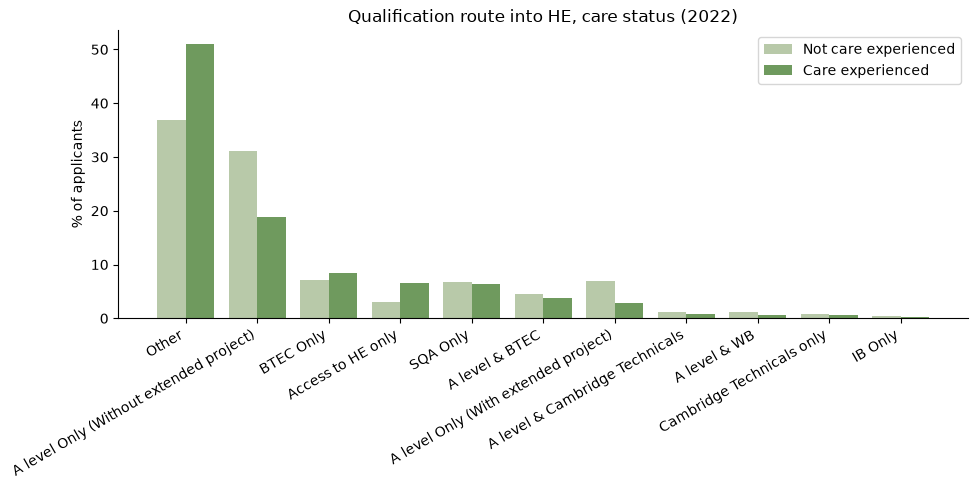

In [17]:
qual_piv, qy = compare_breakdown('Care-experienced applicants - qualification group.csv',
                                  'Qualification group')
# add over-index ratio: how many times more likely CE take each route
qual_piv = qual_piv.copy()
if 'Care experienced' in qual_piv and 'Not care experienced' in qual_piv:
    qual_piv['over_index'] = qual_piv['Care experienced'] / qual_piv['Not care experienced']
qual_piv = qual_piv.sort_values('Care experienced', ascending=False)
print(f"Qualification route, {qy} (share of applicants, and CE over-index):")
print(qual_piv.to_string())

grouped_bar(qual_piv[['Care experienced', 'Not care experienced']]
            if 'Not care experienced' in qual_piv else qual_piv,
            f'Qualification route into HE, care status ({qy})',
            savename='ucas_qualification_route.png', rotate=30, figsize=(10, 5))

- **Access to HE:** care-experienced applicants are 4.5x as likely to arrive via Access to HE, which is the single strongest over-indexing story in the UCAS data. This is a key intersectional disadvantage finding.
- **A-levels:** care-experienced applicants are 0.6x as likely to arrive via A levels, which is the single strongest under-indexing story in the UCAS data
- **Scottish Highers:** care-experienced applicants are 0.5x as likely to arrive via Scottish Highers, which is the second strongest under-indexing story in the UCAS data
- **BTEC:** care-experienced applicants are 1.2x as likely to arrive via BTEC, which is the second strongest over-indexing story in the UCAS data
- **Other:** care-experienced applicants are 1.3x as likely to arrive via Other qualifications, which is the third strongest over-indexing story in the UCAS data

### 16b. Attainment — A level points

Among those taking A levels, how does attainment compare? (GCSE, BTEC and Scottish Highers files follow the same shape if you want to add them.)

A level points distribution, 2022:
Care category   Care experienced  Not care experienced
A level points                                        
10 - 12 points              31.9                  27.0
13 - 15 points              25.8                  30.4
16 - 18 points              11.7                  23.7
3 - 9 points                30.6                  18.9


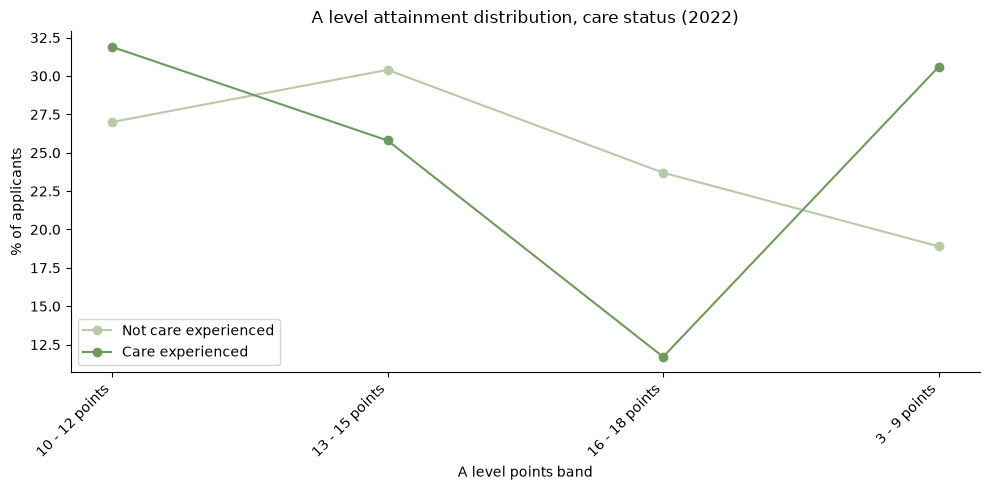

In [18]:
alevel = load_ucas('Care-experienced applicants - A level attainment.csv')
acol = [c for c in alevel.columns if 'A level points' in c][0]
ay = int(alevel['Year'].max())

apiv = (alevel[alevel['Year'] == ay]
        .pivot_table(index=acol, columns='Care category', values='Proportion of applicants'))
print(f"A level points distribution, {ay}:")
print(apiv.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
for cat, color in [('Not care experienced', '#b8c9a9'), ('Care experienced', '#6f9a5e')]:
    if cat in apiv.columns:
        ax.plot(apiv.index.astype(str), apiv[cat].values, marker='o', label=cat, color=color)
ax.set_xlabel('A level points band'); ax.set_ylabel('% of applicants')
ax.set_title(f'A level attainment distribution, care status ({ay})')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'ucas_alevel_attainment.png', dpi=150)
plt.show()

## 17. Theme — intersectional disadvantage

Care experience rarely travels alone. Two cuts: **POLAR4** (do care-experienced applicants also come disproportionately from low-participation areas?) and **duration of care** (does longer time in care track with the patterns we see?).

### 17a. POLAR4 — stacked disadvantage

POLAR4 quintile 1 = lowest HE-participation areas. If care-experienced applicants skew toward Q1, that's two layers of disadvantage stacking, a key intersectional finding.

POLAR4 quintile distribution, 2022 (Q1 = most disadvantaged):
Care category    Care experienced  Not care experienced
POLAR4 quintile                                        
Quintile 1                   18.4                  13.3
Quintile 2                   19.1                  16.2
Quintile 3                   19.9                  19.1
Quintile 4                   20.2                  22.3
Quintile 5                   22.2                  29.0


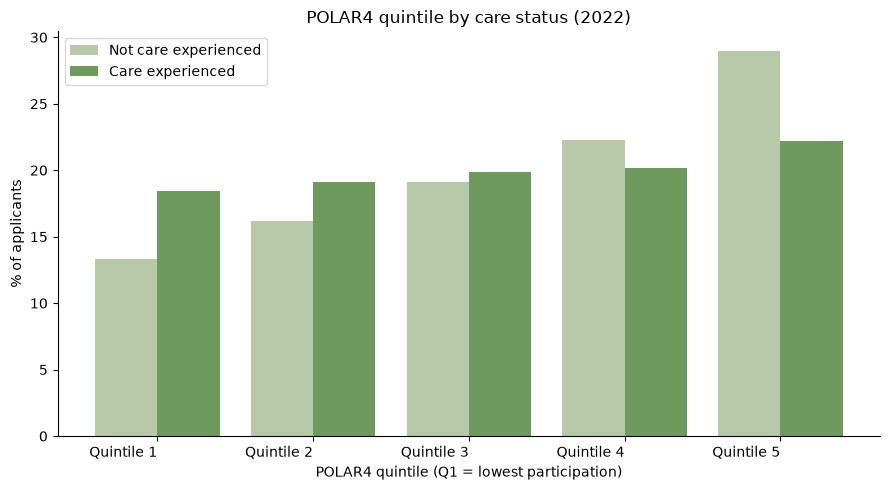


Q1 (most disadvantaged): care-experienced 18.4% vs others 13.3% -> 1.4x over-represented


In [19]:
POLAR_ORDER = ['Quintile 1', 'Quintile 2', 'Quintile 3', 'Quintile 4', 'Quintile 5']
polar = load_ucas('Care-experienced applicants - POLAR4.csv')
pcol = [c for c in polar.columns if 'POLAR4' in c][0]

# try to match the quintile label format actually present
present = list(polar[pcol].dropna().unique())
order = [q for q in POLAR_ORDER if q in present] or sorted(present)

ppiv, py = compare_breakdown('Care-experienced applicants - POLAR4.csv', pcol, order=order)
print(f"POLAR4 quintile distribution, {py} (Q1 = most disadvantaged):")
print(ppiv.to_string())

grouped_bar(ppiv, f'POLAR4 quintile by care status ({py})',
            xlabel='POLAR4 quintile (Q1 = lowest participation)',
            savename='ucas_polar4.png', rotate=0)

if 'Care experienced' in ppiv.columns and order and order[0] in ppiv.index:
    q1_ce = ppiv.loc[order[0], 'Care experienced']
    q1_nce = ppiv.loc[order[0], 'Not care experienced'] if 'Not care experienced' in ppiv else None
    if q1_nce:
        print(f"\nQ1 (most disadvantaged): care-experienced {q1_ce:.1f}% vs others {q1_nce:.1f}% "
              f"-> {q1_ce/q1_nce:.1f}x over-represented")

### 17b. Duration of care

Duration of care among care-experienced applicants, 2022:
Duration of care
Less than 1 week      1.8
1 week - 3 months     9.4
3 months - 1 year    18.7
1 year - 3 years     25.2
3 years or more      44.9


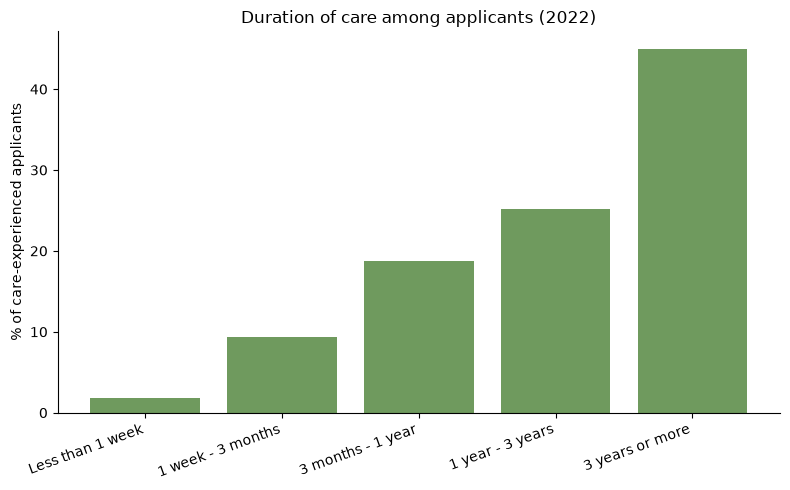

In [20]:
dur = load_ucas('Care-experienced applicants - duration of care.csv')
dcol = [c for c in dur.columns if 'Duration' in c][0]
dy = int(dur['Year'].max())
# duration is care-experienced only (non-care have no duration), so show its own distribution
dsub = dur[(dur['Year'] == dy) & (dur['Care category'] == 'Care experienced')]
dser = dsub.set_index(dcol)['Proportion of applicants'].dropna()
print(f"Duration of care among care-experienced applicants, {dy}:")
print(dser.to_string())

if len(dser):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(dser.index.astype(str), dser.values, color='#6f9a5e')
    ax.set_ylabel('% of care-experienced applicants')
    ax.set_title(f'Duration of care among applicants ({dy})')
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'ucas_duration_of_care.png', dpi=150)
    plt.show()

## 18. Theme — what do they study?

The subject file is the richest (277 rows, many subject groups). The interesting question isn't the raw counts but **where care-experienced applicants over- and under-index** relative to other applicants, which subjects they're drawn to, and which they're missing from.

Subjects care-experienced applicants OVER-index in (2022):
Care category                                         Care experienced  Not care experienced  diff
Subject group (CAH2)                                                                              
(CAH02-04) nursing and midwifery                                  13.5                   8.0   5.5
(CAH15-04) health and social care                                  5.6                   2.1   3.5
(CAH15-01) sociology, social policy and anthropology               5.8                   4.3   1.5
(CAH16-01) law                                                     6.0                   4.9   1.1
(CAH25-02) performing arts                                         4.2                   3.2   1.0
(CAH04-01) psychology                                              6.4                   5.4   1.0
(CAH23-01) combined and general studies                            0.5                   0.4   0.1
(CAH20-02) philosophy and religious studies       

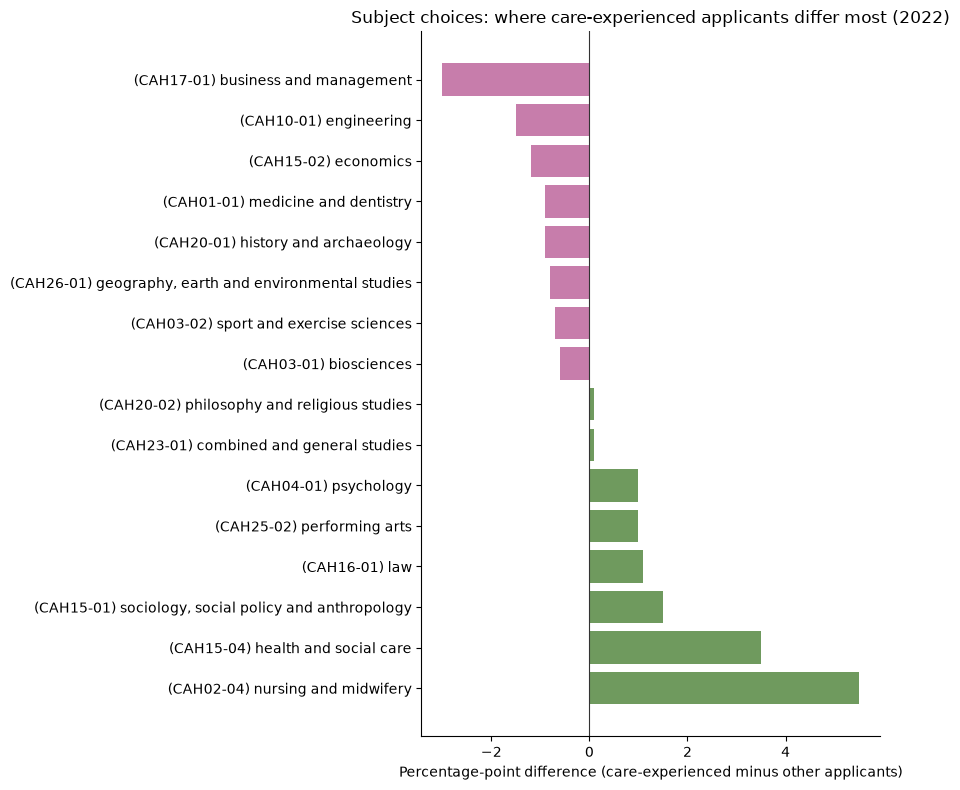

In [21]:
subj = load_ucas('Care-experienced applicants - subject group.csv')
scol = [c for c in subj.columns if 'Subject group' in c][0]
prop = [c for c in subj.columns if 'Proportion of' in c and 'applic' in c.lower()][0]
sy = int(subj['Year'].max())

spiv = (subj[subj['Year'] == sy]
        .pivot_table(index=scol, columns='Care category', values=prop)
        .dropna())
if 'Care experienced' in spiv and 'Not care experienced' in spiv:
    spiv['diff'] = spiv['Care experienced'] - spiv['Not care experienced']
    spiv['over_index'] = spiv['Care experienced'] / spiv['Not care experienced']
    ranked = spiv.sort_values('diff', ascending=False)

    print(f"Subjects care-experienced applicants OVER-index in ({sy}):")
    print(ranked.head(8)[['Care experienced', 'Not care experienced', 'diff']].to_string())
    print(f"\nSubjects they UNDER-index in:")
    print(ranked.tail(8)[['Care experienced', 'Not care experienced', 'diff']].to_string())

    # Diverging bar of biggest over/under indexes
    top = pd.concat([ranked.head(8), ranked.tail(8)])
    fig, ax = plt.subplots(figsize=(9, 8))
    colors = ['#6f9a5e' if v > 0 else '#c77dab' for v in top['diff']]
    ax.barh(top.index, top['diff'], color=colors)
    ax.axvline(0, color='#333', lw=0.8)
    ax.set_xlabel('Percentage-point difference (care-experienced minus other applicants)')
    ax.set_title(f'Subject choices: where care-experienced applicants differ most ({sy})')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'ucas_subject_divergence.png', dpi=150)
    plt.show()
else:
    print("Care category columns not both present, inspect:", list(spiv.columns))

## 19. Theme — lived experience (survey colour)

The survey files capture what the application data can't: how care-experienced applicants *feel* about the journey. These tables aren't tidy (display-formatted, Windows encoding), so this section reads them more defensively and pulls a couple worth visualising as narrative colour.

> These are survey responses from care-experienced applicants only (no comparison group), so they illustrate experience, not gaps. Treat as qualitative colour, not hard comparison.

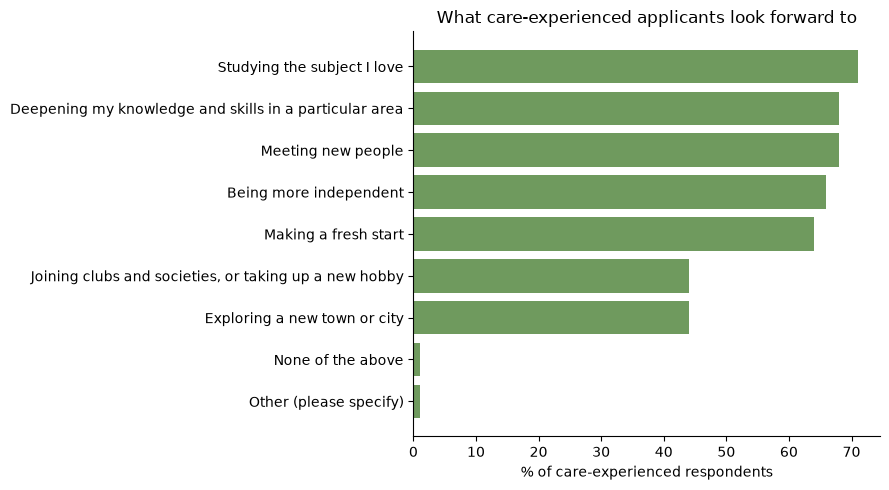

In [22]:
import csv

def read_survey(filename):
    """Survey files are display tables: read raw, find the data rows heuristically."""
    path = UCAS_DIR / filename
    rows = []
    for enc in ('latin-1', 'utf-8'):
        try:
            with open(path, encoding=enc) as f:
                rows = list(csv.reader(f))
            break
        except Exception:
            continue
    # keep rows that look like 'label, number%' pairs
    data = []
    for r in rows:
        if len(r) >= 2:
            label = r[0].strip().strip('-').strip()
            val = r[1].strip().replace('%', '')
            try:
                num = float(val)
                if label and not label.startswith('Care experience'):
                    data.append((label, num))
            except ValueError:
                continue
    return data

# Example 1: what are they looking forward to
look = read_survey('Care experience survey - What are they looking forward to.csv')
if look:
    look = sorted(look, key=lambda x: x[1], reverse=True)[:10]
    labels, vals = zip(*look)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(list(labels)[::-1], list(vals)[::-1], color='#6f9a5e')
    ax.set_xlabel('% of care-experienced respondents')
    ax.set_title('What care-experienced applicants look forward to')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'ucas_looking_forward.png', dpi=150)
    plt.show()
else:
    print("Could not parse 'looking forward' survey, structure may differ, inspect raw.")

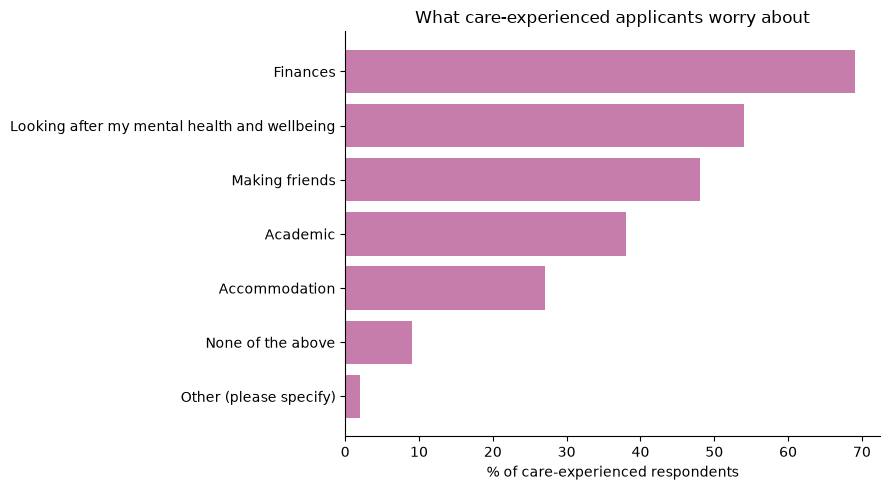

In [23]:
# Example 2: concerns about starting university
concerns = read_survey('Care experience survey - Concerns about starting university or college.csv')
if concerns:
    concerns = sorted(concerns, key=lambda x: x[1], reverse=True)[:10]
    labels, vals = zip(*concerns)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(list(labels)[::-1], list(vals)[::-1], color='#c77dab')
    ax.set_xlabel('% of care-experienced respondents')
    ax.set_title('What care-experienced applicants worry about')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'ucas_concerns.png', dpi=150)
    plt.show()
else:
    print("Could not parse 'concerns' survey, inspect raw structure.")

## 20. Chapter 2 expanded — what we found, for the writeup

Hard-data findings (care-experienced vs other applicants, computed from UCAS files):
- **Age:** care-experienced applicants are roughly twice as likely to apply at 21+.
- **Route:** they arrive via Access to HE and other non-A-level routes at far higher rates, the Access to HE over-index is the headline here.
- **Selectivity:** under-represented at higher-tariff providers, echoing Chapter 1's high-tariff gap from the applicant side.
- **Intersectionality:** POLAR4 skew shows care experience stacking with area-based disadvantage.
- **Subject:** distinct over/under-index pattern in what they choose to study.

Lived experience (survey, care-experienced only, qualitative colour):
- What they look forward to, and what they worry about, starting HE.

**Honesty notes for the site:**
- Two datasets (DfE access, UCAS applications), two cohorts, never chained into one funnel.
- Application data, not outcomes, continuation/completion/attainment for care leavers isn't open yet (HESA building it).
- UCAS care-experienced = self-identified (undercount). Survey = applicants only, no comparison group.
- Suppression: small care-experienced cells are blank, note rather than interpolate.